In [1]:
from pathlib import Path
import os, stat, glob, traceback
import numpy as np
import pandas as pd
import arviz as az
from arviz_stats.base.array import array_stats
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt

/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [ ]:
stan_dir = Path('../stan').resolve()
out_root = Path.cwd() / 'stan_output'
out_root.mkdir(parents=True, exist_ok=True)
models = {
    'minimal': {'file': stan_dir / 'minimal.stan', 'outdir': out_root / 'minimal'},
    'province': {'file': stan_dir / 'logistic_province.stan', 'outdir': out_root / 'province'},
    'full': {'file': stan_dir / 'logistic_full.stan', 'outdir': out_root / 'full'},
    'response': {'file': stan_dir / 'logistic_response.stan', 'outdir': out_root / 'response'},
}
for m in models.values():
    m['outdir'].mkdir(parents=True, exist_ok=True)

def compile_model(stan_path):
    print('Compiling', stan_path.name)
    mdl = CmdStanModel(stan_file=str(stan_path))
    mode = os.stat(mdl.exe_file).st_mode
    os.chmod(mdl.exe_file, mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    return mdl

In [ ]:
idata_min = az.from_netcdf(str(models['minimal']['outdir'] / 'idata.nc'))
idata_prov = az.from_netcdf(str(models['province']['outdir'] / 'idata.nc'))
idata_full = az.from_netcdf(str(models['full']['outdir'] / 'idata.nc'))
idata_response = az.from_netcdf(str(models['response']['outdir'] / 'idata.nc'))
print('Loaded saved idata for: minimal, province, full, response')

In [ ]:
model_idata = {
    'minimal': idata_min,
    'province': idata_prov,
    'full': idata_full,
    'response': idata_response,
}
print('Models:', list(model_idata.keys()))

Models: ['minimal', 'province', 'full', 'response']


In [ ]:
rows = []
for name, idata in model_idata.items():
    has_posterior = hasattr(idata, "posterior")
    has_log_lik = hasattr(idata, "log_likelihood")
    has_ppc = hasattr(idata, "posterior_predictive")

    n_vars = len(idata.posterior.data_vars) if has_posterior else 0
    n_draws = (
        idata.posterior.sizes.get("chain", 1) * idata.posterior.sizes.get("draw", 0)
        if has_posterior else 0
    )

    rows.append({
        "model": name,
        "has_posterior": has_posterior,
        "has_log_likelihood": has_log_lik,
        "has_posterior_predictive": has_ppc,
        "n_posterior_vars": n_vars,
        "n_draws_total": int(n_draws),
    })

pd.DataFrame(rows).set_index("model")

,has_posterior,has_log_likelihood,has_posterior_predictive,n_posterior_vars,n_draws_total
model,,,,,
minimal,True,True,True,3,4000
province,True,True,True,4,4000
full,True,True,True,6,4000
response,True,True,True,7,4000


In [ ]:
loo_min = az.loo(model_idata['minimal'], pointwise=True)
print(loo_min)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2246.76    73.78
p_loo        3.17        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [ ]:
loo_prov = az.loo(model_idata['province'], pointwise=True)
print(loo_prov)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2018.97    66.52
p_loo       10.57        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [ ]:
loo_full = az.loo(model_idata['full'], pointwise=True)
print(loo_full)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1870.54    63.06
p_loo       16.02        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [ ]:
loo_response = az.loo(model_idata['response'], pointwise=True)
print(loo_response)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1864.94    63.05
p_loo       18.51        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [4]:
spatial_vi_csvs = sorted((out_root / 'spatial_vi').glob('*.csv'))
if len(spatial_vi_csvs) == 0:
    raise FileNotFoundError('No VI CSV found in notebooks/stan_output/spatial_vi')

spatial_vi_csv = spatial_vi_csvs[-1]
spatial_vi_df = pd.read_csv(spatial_vi_csv, comment='#')

import re
ll_cols_sp = [c for c in spatial_vi_df.columns if c.startswith('log_lik[')]
if len(ll_cols_sp) == 0:
    ll_cols_sp = [c for c in spatial_vi_df.columns if c.startswith('log_lik.')]
if len(ll_cols_sp) == 0:
    ll_cols_sp = [c for c in spatial_vi_df.columns if c.startswith('log_lik')]
if len(ll_cols_sp) == 0:
    raise KeyError('No log_lik columns found in spatial VI CSV')

def _ll_key(c):
    m = re.search(r'(?:\[|\.)(\d+)$', c)
    return int(m.group(1)) if m else 10**9
ll_cols_sp = sorted(ll_cols_sp, key=_ll_key)

log_lik_arr_sp = spatial_vi_df[ll_cols_sp].to_numpy()[None, :, :]
idata_spatial_vi_cmp = az.from_dict(
    {'log_likelihood': {'y': log_lik_arr_sp}},
    dims={'y': ['obs_id']},
)
loo_spatial_vi_cmp = az.loo(idata_spatial_vi_cmp, var_name='y', pointwise=True, reff=1.0)
print(loo_spatial_vi_cmp)

Computed from 1001 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1867.79    63.33
p_loo       41.06        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.67]   (good)     15203  100.0%
   (0.67, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [ ]:
comp = az.compare({
    'minimal': loo_min,
    'province': loo_prov,
    'full': loo_full,
    'response': loo_response,
    'spatial_vi': loo_spatial_vi_cmp,
}, round_to='none')

comp

,rank,elpd,p,elpd_diff,weight,se,dse,warning
response,0,-1864.937186,18.506443,0.000000,0.512460,63.045831,0.000000,False
spatial_vi,1,-1867.786052,41.057997,2.848866,0.482349,63.326315,9.216537,False
full,2,-1870.535278,16.016552,5.598092,0.000000,63.062419,3.491616,False
province,3,-2018.968597,10.566749,154.031411,0.000000,66.522598,17.558547,False
minimal,4,-2246.755781,3.166470,381.818595,0.005191,73.775145,28.806468,False


In [ ]:
import re

df_all = pd.read_csv('../data/fire_db.csv')

df_prov = df_all.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator','province']).copy()
prov_cat_prov = pd.Categorical(df_prov['province'])

df_full_c = df_all.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator','log_dist_to_fn_km','n_fn_20km','fire_cause','fire_type','protection_zone','province']).copy()
prov_cat_full = pd.Categorical(df_full_c['province'])
prot_cat_full = pd.Categorical(df_full_c['protection_zone'])

df_resp_c = df_all.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator','log_dist_to_fn_km','n_fn_20km','fire_cause','fire_type','protection_zone','response_type','province']).copy()
prov_cat_resp = pd.Categorical(df_resp_c['province'])
prot_cat_resp = pd.Categorical(df_resp_c['protection_zone'])
resp_cat = pd.Categorical(df_resp_c['response_type'])

CATEGORY_MAPS = {
    'minimal': {},
    'province': {
        'a_prov': list(prov_cat_prov.categories),
    },
    'full': {
        'a_prov': list(prov_cat_full.categories),
        'a_prot': list(prot_cat_full.categories),
    },
    'response': {
        'a_prov': list(prov_cat_resp.categories),
        'a_prot': list(prot_cat_resp.categories),
        'a_response': list(resp_cat.categories),
    },
}

def _label_param(name, cat_map):
    m = re.match(r'^(a_prov|a_prot|a_response)\[(\d+)\]$', str(name))
    if m is None:
        return str(name)

    base = m.group(1)
    raw_idx = int(m.group(2))
    labels = cat_map.get(base)
    if labels is None:
        return str(name)

    if 0 <= raw_idx < len(labels):
        idx = raw_idx
    elif 1 <= raw_idx <= len(labels):
        idx = raw_idx - 1
    else:
        return str(name)

    prefix = {'a_prov': 'prov', 'a_prot': 'prot', 'a_response': 'response'}[base]
    return f"{prefix}: {labels[idx]}"

def summary_with_labels(idata, model_name):
    out = az.summary(idata)
    cat_map = CATEGORY_MAPS.get(model_name, {})
    out = out.copy()
    out.index = [_label_param(v, cat_map) for v in out.index]
    return out

In [ ]:
summary_with_labels(idata_min, 'minimal')

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-3.434,0.049,-3.5,-3.4,2880,2878,1.00,0.00091,0.00063
beta_log_fire_size,0.38,0.041,0.32,0.44,3135,2732,1.00,0.00073,0.00051
beta_fn,1.44,0.204,1.1,1.8,3142,2147,1.00,0.0037,0.0026


In [ ]:
summary_with_labels(idata_prov, 'province')

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-4.05,0.32,-4.6,-3.5,756,1134,1.00,0.012,0.0079
prov: AB,1.29,0.34,0.74,1.8,839,1341,1.00,0.012,0.008
prov: BC,1.82,0.33,1.3,2.4,793,1215,1.00,0.012,0.0079
prov: MB,0.54,0.34,0.0026,1.1,815,1236,1.00,0.012,0.0082
prov: NB,-0.49,0.84,-1.9,0.81,3985,2679,1.00,0.013,0.0095
prov: NL,-1.43,0.69,-2.6,-0.39,3162,2692,1.00,0.012,0.0097
prov: NS,-0.31,0.93,-1.8,1.2,2758,2341,1.00,0.018,0.012
prov: NT,-1.86,0.44,-2.6,-1.2,1367,1967,1.00,0.012,0.0081
prov: ON,1.04,0.34,0.51,1.6,806,1155,1.00,0.012,0.0081
prov: PC,-0.1,0.44,-0.82,0.62,1400,1865,1.00,0.012,0.0083


In [ ]:
summary_with_labels(idata_full, 'full')

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-3.89,0.51,-4.7,-3.1,1024,1214,1.00,0.016,0.011
prov: AB,1.11,0.35,0.55,1.7,901,1495,1.01,0.012,0.0081
prov: BC,1.53,0.34,0.99,2.1,865,1350,1.01,0.012,0.008
prov: MB,-0.4,0.36,-0.98,0.21,962,1637,1.01,0.012,0.0081
prov: NB,-0.9,0.77,-2.2,0.28,4310,2395,1.00,0.012,0.0086
prov: NL,-0.96,0.73,-2.2,0.17,3628,2698,1.00,0.012,0.0086
prov: NS,-0.36,0.87,-1.7,1,5703,2925,1.00,0.011,0.0078
prov: NT,-0.7,0.49,-1.5,0.077,1685,2510,1.00,0.012,0.0082
prov: ON,0.99,0.35,0.44,1.5,877,1411,1.01,0.012,0.008
prov: PC,-0.16,0.45,-0.9,0.54,1529,2098,1.00,0.011,0.0079


In [ ]:
summary_with_labels(idata_response, 'response')

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-3.97,0.68,-5,-2.9,1636,2181,1.00,0.017,0.012
prov: AB,1.01,0.34,0.48,1.6,1477,2069,1.00,0.0089,0.0062
prov: BC,1.51,0.33,0.99,2,1404,1725,1.00,0.0088,0.0062
prov: MB,-0.37,0.35,-0.93,0.19,1571,1924,1.00,0.0088,0.0063
prov: NB,-0.9,0.73,-2.1,0.22,4552,3056,1.00,0.011,0.0083
prov: NL,-1,0.75,-2.2,0.16,4863,3053,1.00,0.011,0.0077
prov: NS,-0.35,0.88,-1.8,1,5039,2739,1.00,0.013,0.0089
prov: NT,-0.58,0.47,-1.3,0.17,2437,2844,1.00,0.0096,0.0068
prov: ON,1.27,0.34,0.73,1.8,1557,2096,1.00,0.0087,0.0061
prov: PC,-0.09,0.43,-0.79,0.59,2223,2472,1.00,0.0091,0.0065


In [ ]:
req_cols_sp = [
    'any_evacuation', 'log_fire_size_ha', 'log_dist_to_fn_km', 'fn_indicator',
    'province', 'protection_zone', 'latitude', 'longitude',
]
df_sp_labels = df_all.dropna(subset=req_cols_sp).copy()
prov_labels_sp = list(pd.Categorical(df_sp_labels['province']).categories)
prot_labels_sp = list(pd.Categorical(df_sp_labels['protection_zone']).categories)
spatial_cat_map = {'a_prov': prov_labels_sp, 'a_prot': prot_labels_sp}

def _label_spatial_param(name):
    m = re.match(r'^(a_prov|a_prot|u_region)(?:\[|\.)(\d+)\]?$', str(name))
    if m is None:
        return str(name)
    base = m.group(1)
    raw_idx = int(m.group(2))
    if base == 'u_region':
        return f'region: {raw_idx}'
    labels = spatial_cat_map.get(base, [])
    if raw_idx < 1 or raw_idx > len(labels):
        return str(name)
    prefix = {'a_prov': 'prov', 'a_prot': 'prot'}[base]
    return f"{prefix}: {labels[raw_idx - 1]}"

exclude_cols = {'lp__', 'log_p__', 'log_g__'}
spatial_param_cols = [
    c for c in spatial_vi_df.columns
    if c not in exclude_cols and not c.startswith('y_rep') and not c.startswith('log_lik')
]

spatial_posterior_summary_vi = pd.DataFrame({
    'variable': [_label_spatial_param(c) for c in spatial_param_cols],
    'mean': spatial_vi_df[spatial_param_cols].mean().values,
    'sd': spatial_vi_df[spatial_param_cols].std(ddof=1).values,
    'ci_2.5%': spatial_vi_df[spatial_param_cols].quantile(0.025).values,
    'ci_97.5%': spatial_vi_df[spatial_param_cols].quantile(0.975).values,
}).sort_values('variable').reset_index(drop=True)

spatial_posterior_summary_vi

,variable,mean,sd,ci_2.5%,ci_97.5%
0,alpha,-2.565568,0.048300,-2.663411,-2.470988
1,beta_dist,-0.982998,0.037770,-1.058116,-0.910308
2,beta_fn,-0.875241,0.206624,-1.287140,-0.468952
3,beta_log_fire_size,0.548592,0.042971,0.463051,0.633227
4,prot: intensive,-0.506042,0.146066,-0.790163,-0.229291
...,...,...,...,...,...
165,region: 96,-0.412305,0.242767,-0.866582,0.048043
166,region: 97,-0.203448,0.213705,-0.646116,0.216506
167,region: 98,-0.598650,0.216957,-1.009553,-0.174145
168,region: 99,-0.223426,0.185017,-0.571418,0.132225


In [7]:
import re

region_cols = [
    c for c in spatial_vi_df.columns
    if c.startswith('u_region.') or c.startswith('u_region[')
]
if len(region_cols) == 0:
    raise ValueError('No region random-effect columns found (expected u_region.<idx> or u_region[<idx>])')

region_means = spatial_vi_df[region_cols].mean().sort_values()

def _region_idx(col_name: str) -> int:
    m = re.search(r'(?:\.|\[)(\d+)(?:\])?$', col_name)
    if m is None:
        raise ValueError(f'Could not parse region index from {col_name}')
    return int(m.group(1))

region_labels = spatial_cat_map.get('u_region', []) if 'spatial_cat_map' in globals() else []

min_col = region_means.index[0]
max_col = region_means.index[-1]
min_idx = _region_idx(min_col)
max_idx = _region_idx(max_col)

min_label = region_labels[min_idx - 1] if 1 <= min_idx <= len(region_labels) else f'region {min_idx}'
max_label = region_labels[max_idx - 1] if 1 <= max_idx <= len(region_labels) else f'region {max_idx}'

result_region_extremes = pd.DataFrame({
    'type': ['min_region_mean', 'max_region_mean'],
    'column': [min_col, max_col],
    'region_label': [min_label, max_label],
    'mean': [region_means.iloc[0], region_means.iloc[-1]],
})

result_region_extremes

,type,column,region_label,mean
0,min_region_mean,u_region.109,region 109,-1.429486
1,max_region_mean,u_region.108,region 108,1.167795


## Posterior Comparison: Full MCMC vs Full VI

Using VI draws from: logistic_full-20260419100027.csv


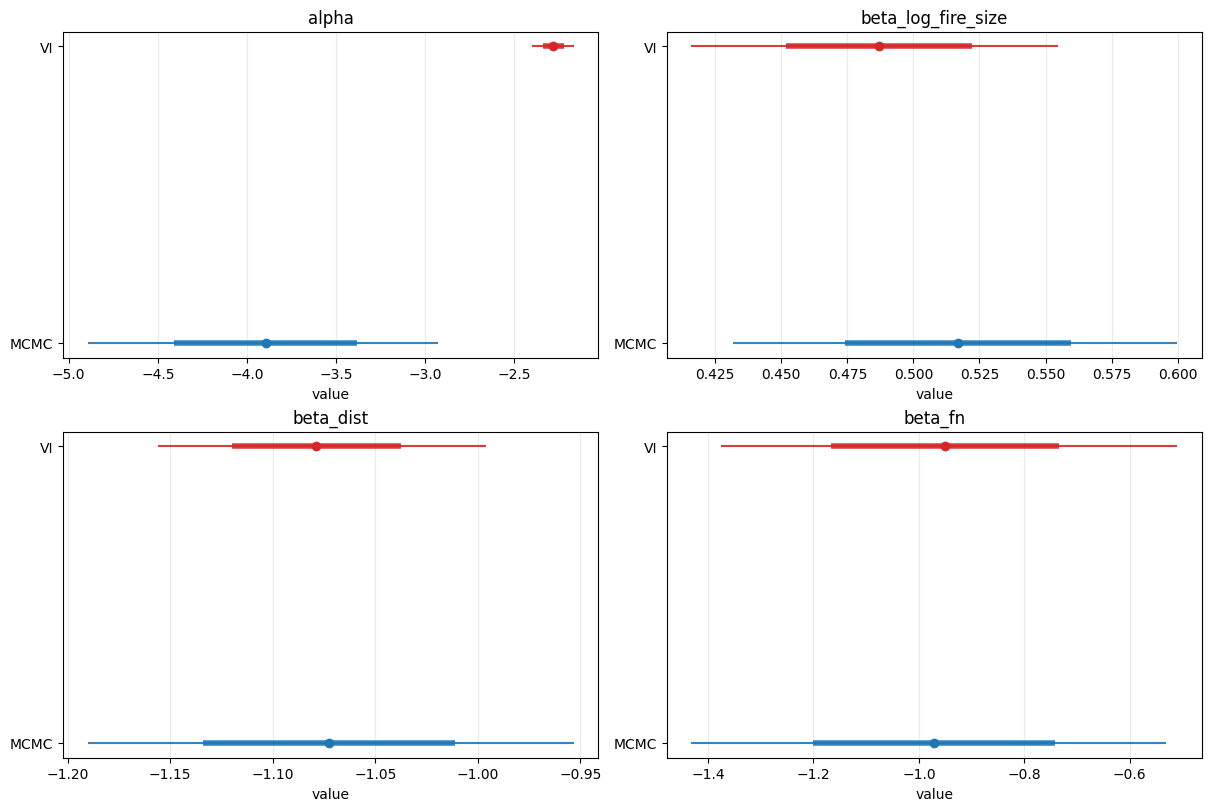

,param,method,mean,sd,q025,q50,q975,width_95
0,alpha,MCMC,-3.894742,0.514176,-4.894299,-3.879007,-2.926701,1.967597
1,alpha,VI,-2.281013,0.060749,-2.403049,-2.282258,-2.166512,0.236537
2,beta_dist,MCMC,-1.072788,0.061446,-1.190333,-1.072876,-0.953171,0.237163
3,beta_dist,VI,-1.078715,0.041370,-1.155990,-1.077962,-0.996070,0.159920
4,beta_fn,MCMC,-0.971451,0.230106,-1.432033,-0.965994,-0.531506,0.900526
5,beta_fn,VI,-0.950698,0.216730,-1.375812,-0.934859,-0.509639,0.866172
6,beta_log_fire_size,MCMC,0.516780,0.042661,0.431704,0.517301,0.599851,0.168148
7,beta_log_fire_size,VI,0.486960,0.035312,0.415896,0.487218,0.554730,0.138833


In [ ]:
params = ['alpha', 'beta_log_fire_size', 'beta_dist', 'beta_fn']

vi_csvs = sorted((out_root / 'full_vi').glob('*.csv'))
if len(vi_csvs) == 0:
    raise FileNotFoundError('No VI CSV found in notebooks/stan_output/full_vi')

vi_csv = vi_csvs[-1]
vi_df = pd.read_csv(vi_csv, comment='#')
print('Using VI draws from:', vi_csv.name)

rows = []
for p in params:
    if p not in vi_df.columns:
        raise KeyError(f'Missing VI column: {p}')
    if p not in idata_full.posterior:
        raise KeyError(f'Missing MCMC posterior variable: {p}')

    draws_vi = vi_df[p].to_numpy(dtype=float)
    draws_mcmc = idata_full.posterior[p].values.reshape(-1).astype(float)

    rows.extend([{'param': p, 'method': 'VI', 'draw': x} for x in draws_vi])
    rows.extend([{'param': p, 'method': 'MCMC', 'draw': x} for x in draws_mcmc])

post_df = pd.DataFrame(rows)

summary = (
    post_df.groupby(['param', 'method'])['draw']
    .agg(
        mean='mean',
        sd='std',
        q025=lambda x: x.quantile(0.025),
        q50='median',
        q975=lambda x: x.quantile(0.975),
    )
    .reset_index()
)
summary['width_95'] = summary['q975'] - summary['q025']
summary = summary.sort_values(['param', 'method']).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

method_order = ['MCMC', 'VI']
method_color = {'MCMC': '#1f77b4', 'VI': '#d62728'}

for ax, p in zip(axes, params):
    sub = summary[summary['param'] == p].set_index('method').loc[method_order].reset_index()
    y = np.arange(len(method_order))

    for i, row in sub.iterrows():
        m = row['mean']
        sd = row['sd']
        lo95 = row['q025']
        hi95 = row['q975']
        c = method_color[row['method']]

        # 95% CI whisker
        ax.hlines(y=i, xmin=lo95, xmax=hi95, color=c, linewidth=1.5, alpha=0.9)
        # +/- 1 SD thicker segment
        ax.hlines(y=i, xmin=m - sd, xmax=m + sd, color=c, linewidth=4, alpha=0.9)
        # Mean point
        ax.plot(m, i, 'o', color=c, markersize=6)

    ax.set_yticks(y)
    ax.set_yticklabels(method_order)
    ax.set_title(p)
    ax.set_xlabel('value')
    ax.grid(axis='x', alpha=0.25)

plt.show()

summary

## PPC: interval for total number of evacuations by model

In [ ]:
rows = []
for name, idata in model_idata.items():
    ppc = idata.posterior_predictive
    var_candidates = [v for v in ['y_rep', 'y', 'y_obs'] if v in ppc.data_vars]

    y_var = var_candidates[0]
    arr = ppc[y_var]
    event_dims = [d for d in arr.dims if d not in ('chain', 'draw')]
    totals = arr.sum(dim=event_dims).values.reshape(-1).astype(float)

    rows.append({
        'model': name,
        'pp_total_evac_mean': float(np.mean(totals)),
        'pp_total_evac_ci2.5': float(np.quantile(totals, 0.025)),
        'pp_total_evac_ci97.5': float(np.quantile(totals, 0.975)),
    })

ppc_total_intervals = pd.DataFrame(rows)
ppc_total_intervals

,model,pp_total_evac_mean,pp_total_evac_ci2.5,pp_total_evac_ci97.5
0,minimal,531.87900,472.0,595.025
1,province,532.41475,471.0,595.025
2,full,531.54825,473.0,592.000
3,response,532.45075,475.0,593.000


In [ ]:
# Spatial VI posterior predictive check: total evacuations
spatial_y_rep_cols = [c for c in spatial_vi_df.columns if c.startswith('y_rep[')]
if len(spatial_y_rep_cols) == 0:
    spatial_y_rep_cols = [c for c in spatial_vi_df.columns if c.startswith('y_rep.')]
if len(spatial_y_rep_cols) == 0:
    spatial_y_rep_cols = [c for c in spatial_vi_df.columns if c.startswith('y_rep')]
if len(spatial_y_rep_cols) == 0:
    raise KeyError('No y_rep columns found in spatial VI CSV')

def _yrep_key(c):
    m = re.search(r'(?:\[|\.)(\d+)$', c)
    return int(m.group(1)) if m else 10**9
spatial_y_rep_cols = sorted(spatial_y_rep_cols, key=_yrep_key)

spatial_y_rep_arr = spatial_vi_df[spatial_y_rep_cols].to_numpy(dtype=float)
spatial_y_rep_totals = spatial_y_rep_arr.sum(axis=1)

spatial_ppc_total_intervals = pd.DataFrame([{
    'model': 'spatial_vi',
    'pp_total_evac_mean': float(np.mean(spatial_y_rep_totals)),
    'pp_total_evac_ci2.5': float(np.quantile(spatial_y_rep_totals, 0.025)),
    'pp_total_evac_ci97.5': float(np.quantile(spatial_y_rep_totals, 0.975)),
}])

spatial_ppc_total_intervals

,model,pp_total_evac_mean,pp_total_evac_ci2.5,pp_total_evac_ci97.5
0,spatial_vi,537.947053,448.0,636.0


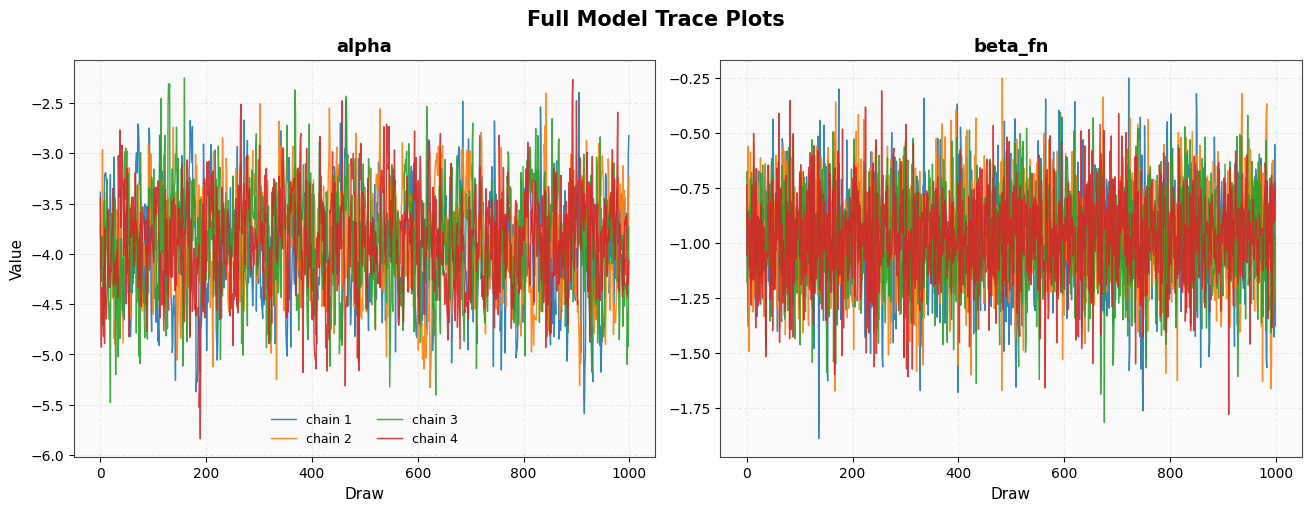

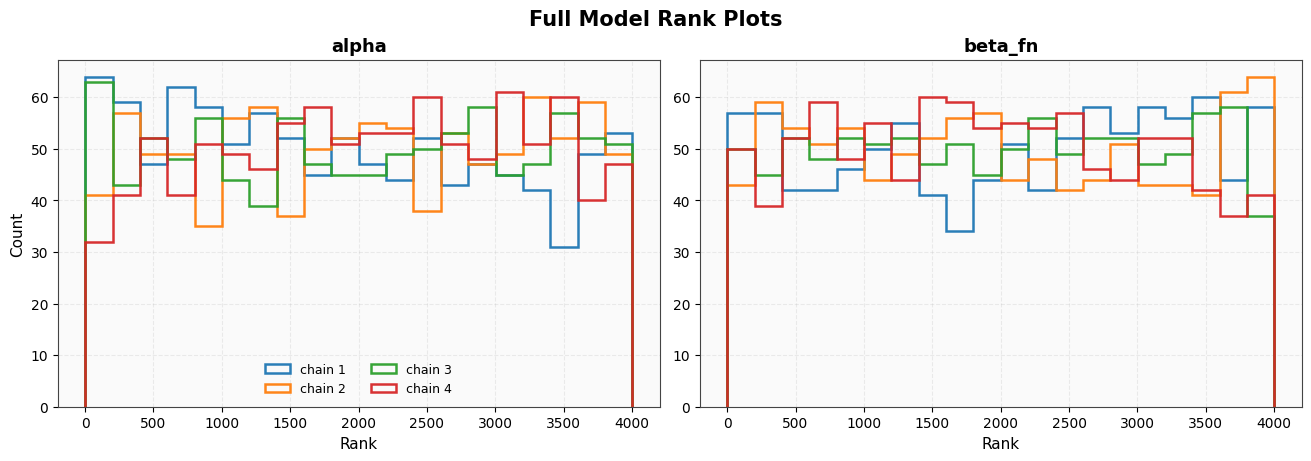

Saved: /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/figures/full_trace_alpha_beta_fn.png
Saved: /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/figures/full_rank_alpha_beta_fn.png


In [ ]:
# Full model diagnostics: prettier custom trace and rank plots for alpha and beta_fn
params_diag = ['alpha', 'beta_fn']
chain_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig_dir = out_root / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
trace_path = fig_dir / 'full_trace_alpha_beta_fn.png'
rank_path = fig_dir / 'full_rank_alpha_beta_fn.png'

def _compute_ranks_per_chain(vals_2d):
    flat = vals_2d.reshape(-1)
    ranks = np.argsort(np.argsort(flat)) + 1
    return ranks.reshape(vals_2d.shape)

plot_style = {
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#444444',
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.linestyle': '--',
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
}

with plt.rc_context(plot_style):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for ax, p in zip(axes, params_diag):
        vals = idata_full.posterior[p].values  # (chain, draw)
        n_chains, n_draws = vals.shape[0], vals.shape[1]
        x = np.arange(n_draws)
        for ch in range(n_chains):
            ax.plot(
                x,
                vals[ch, :],
                color=chain_colors[ch % len(chain_colors)],
                linewidth=1.0,
                alpha=0.9,
                label=f'chain {ch + 1}' if p == params_diag[0] else None,
            )
        ax.set_title(p)
        ax.set_xlabel('Draw')
    axes[0].set_ylabel('Value')
    axes[0].legend(frameon=False, ncol=2, fontsize=9)
    fig.suptitle('Full Model Trace Plots', fontsize=15, fontweight='bold')
    fig.savefig(trace_path, dpi=300, bbox_inches='tight')
    plt.show()

with plt.rc_context(plot_style):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    for ax, p in zip(axes, params_diag):
        vals = idata_full.posterior[p].values  # (chain, draw)
        n_chains, n_draws = vals.shape[0], vals.shape[1]
        ranks = _compute_ranks_per_chain(vals)
        bins = np.linspace(1, n_chains * n_draws + 1, 21)
        for ch in range(n_chains):
            ax.hist(
                ranks[ch, :],
                bins=bins,
                histtype='step',
                linewidth=1.8,
                color=chain_colors[ch % len(chain_colors)],
                alpha=0.95,
                label=f'chain {ch + 1}' if p == params_diag[0] else None,
            )
        ax.set_title(p)
        ax.set_xlabel('Rank')
    axes[0].set_ylabel('Count')
    axes[0].legend(frameon=False, ncol=2, fontsize=9)
    fig.suptitle('Full Model Rank Plots', fontsize=15, fontweight='bold')
    fig.savefig(rank_path, dpi=300, bbox_inches='tight')
    plt.show()

print('Saved:', trace_path)
print('Saved:', rank_path)

In [ ]:
requested_params = [
    ('Alpha', ['alpha']),
    ('beta_Fn', ['beta_fn']),
    ('beta_fire_size', ['beta_log_fire_size', 'beta_fire_size']),
    ('beta_dist_to_fn', ['beta_dist', 'beta_dist_to_fn', 'beta_log_dist_to_fn_km']),
    ('prov: BC', ['prov: BC', 'a_prov[BC]']),
]

def _format_triplet(mean, lo, hi):
    if pd.isna(mean) or pd.isna(lo) or pd.isna(hi):
        return np.nan
    return f"{mean:.3f} [{lo:.3f}, {hi:.3f}]"

def _draw_stats(draws):
    arr = np.asarray(draws, dtype=float).reshape(-1)
    if arr.size == 0:
        return np.nan, np.nan, np.nan
    return float(arr.mean()), float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975))

def _extract_from_mcmc(idata, model_name, display_name, candidate_names):
    posterior = idata.posterior

    if display_name == 'prov: BC':
        if 'a_prov' not in posterior:
            return np.nan, np.nan, np.nan
        prov_labels = CATEGORY_MAPS.get(model_name, {}).get('a_prov', [])
        if 'BC' not in prov_labels:
            return np.nan, np.nan, np.nan
        idx = prov_labels.index('BC')
        draws = posterior['a_prov'].values[..., idx]
        return _draw_stats(draws)

    for nm in candidate_names:
        if nm in posterior:
            draws = posterior[nm].values
            return _draw_stats(draws)

    return np.nan, np.nan, np.nan

def _extract_from_spatial_vi(display_name, candidate_names):
    sp = spatial_posterior_summary_vi.copy()
    idx_lower = {str(v).lower(): v for v in sp['variable']}

    for nm in candidate_names:
        if nm in set(sp['variable']):
            row = sp.loc[sp['variable'] == nm].iloc[0]
            return float(row['mean']), float(row['ci_2.5%']), float(row['ci_97.5%'])
        key = str(nm).lower()
        if key in idx_lower:
            row = sp.loc[sp['variable'] == idx_lower[key]].iloc[0]
            return float(row['mean']), float(row['ci_2.5%']), float(row['ci_97.5%'])

    return np.nan, np.nan, np.nan

model_idata_for_table = {
    'minimal': idata_min,
    'province': idata_prov,
    'full': idata_full,
    'response': idata_response,
}

rows = []
for model_name in ['minimal', 'province', 'full', 'response', 'spatial_vi']:
    row = {'model': model_name}
    for display_name, candidates in requested_params:
        if model_name == 'spatial_vi':
            mean, lo, hi = _extract_from_spatial_vi(display_name, candidates)
        else:
            mean, lo, hi = _extract_from_mcmc(model_idata_for_table[model_name], model_name, display_name, candidates)

        row[f'{display_name}_mean'] = mean
        row[f'{display_name}_ci2.5'] = lo
        row[f'{display_name}_ci97.5'] = hi
        row[f'{display_name} (mean [95% CI])'] = _format_triplet(mean, lo, hi)
    rows.append(row)

param_table_all_models = pd.DataFrame(rows).set_index('model')

compact_cols = [f'{p[0]} (mean [95% CI])' for p in requested_params]
param_table_all_models[compact_cols]

,Alpha (mean [95% CI]),beta_Fn (mean [95% CI]),beta_fire_size (mean [95% CI]),beta_dist_to_fn (mean [95% CI]),prov: BC (mean [95% CI])
model,,,,,
minimal,"-3.434 [-3.531, -3.342]","1.440 [1.027, 1.810]","0.380 [0.303, 0.459]",NaN,NaN
province,"-4.047 [-4.690, -3.425]","1.220 [0.820, 1.604]","0.486 [0.400, 0.568]",NaN,"1.824 [1.186, 2.479]"
full,"-3.895 [-4.894, -2.927]","-0.971 [-1.432, -0.532]","0.517 [0.432, 0.600]","-1.073 [-1.190, -0.953]","1.531 [0.864, 2.198]"
response,"-3.969 [-5.292, -2.616]","-0.966 [-1.435, -0.515]","0.522 [0.438, 0.608]","-1.059 [-1.186, -0.935]","1.508 [0.877, 2.143]"
spatial_vi,"-2.566 [-2.663, -2.471]","-0.875 [-1.287, -0.469]","0.549 [0.463, 0.633]","-0.983 [-1.058, -0.910]","0.401 [0.221, 0.579]"
